Should take results from model-metrics.py for graphing and other testing in the form of a csv




Consider including WandB for logging and cloud saving.

No manual required. 

In [1]:
#imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import textwrap

# Set a clean visual style for our charts
sns.set_theme(style="whitegrid")

### Inputs

In [ ]:

#inputs

# --- File Paths ---
# Replace the filenames with the exact CSVs generated in your metrics-results folder
csv_path_model1 = "../results/metrics-results/gemma-4b_TestSet_20260425_092945.csv"
csv_path_model2 = "../results/metrics-results/Molmo2-4b_TestSet_20260425_094603.csv" # Leave as a dummy string if Model 2 isn't ready yet

# Path to original images (assuming coco-dataset is one level up from notebooks)
IMAGES_DIR = "../data/coco-dataset/val2017"



In [3]:
#data analysis 

# Updated to handle all available score metrics
def print_summary_stats(df, model_name):
    print(f"--- Summary Statistics for {model_name} ---")
    # Identify all score columns dynamically
    score_cols = [c for c in df.columns if c.endswith('_Score')]
    stats = df[score_cols].agg(['mean', 'median', 'min', 'max']).round(4)
    print(stats)
    print("\n")

df_m1 = pd.read_csv(csv_path_model1)
df_m1['Model'] = 'Gemma 4B'
print_summary_stats(df_m1, "Gemma 4B")

# ... (loading Model 2 logic) ...

# Attempt to load Model 2 (fails gracefully if not run yet)
try:
    df_m2 = pd.read_csv(csv_path_model2)
    df_m2['Model'] = 'Molmo 2 4B'
    print_summary_stats(df_m2, "Molmo 2 4B")
    
    # Combine both into one DataFrame for easy graphing
    df_all = pd.concat([df_m1, df_m2], ignore_index=True)
except FileNotFoundError:
    print("Model 2 CSV not found. Proceeding with only Model 1 data.")
    df_all = df_m1.copy()


--- Summary Statistics for Gemma 4B ---
        CIDER_Score  SPICE_Score  METEOR_Score  CLIP_SCORE_Score
mean         0.1926       0.1821        0.4111            0.3309
median       0.1129       0.1714        0.4038            0.3308
min          0.0000       0.0000        0.0938            0.1965
max          3.5114       0.6486        0.9132            0.4636


Model 2 CSV not found. Proceeding with only Model 1 data.


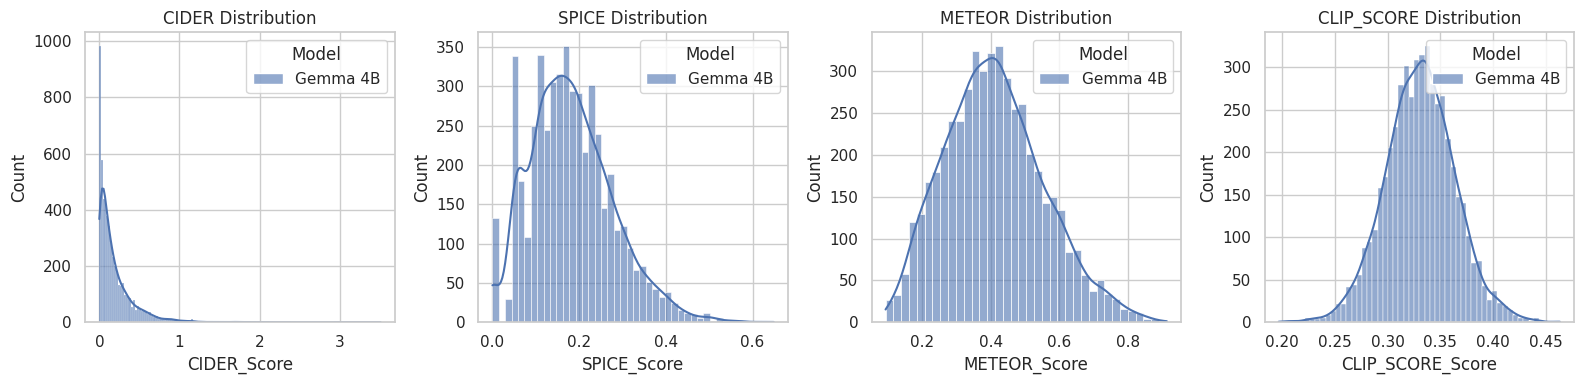

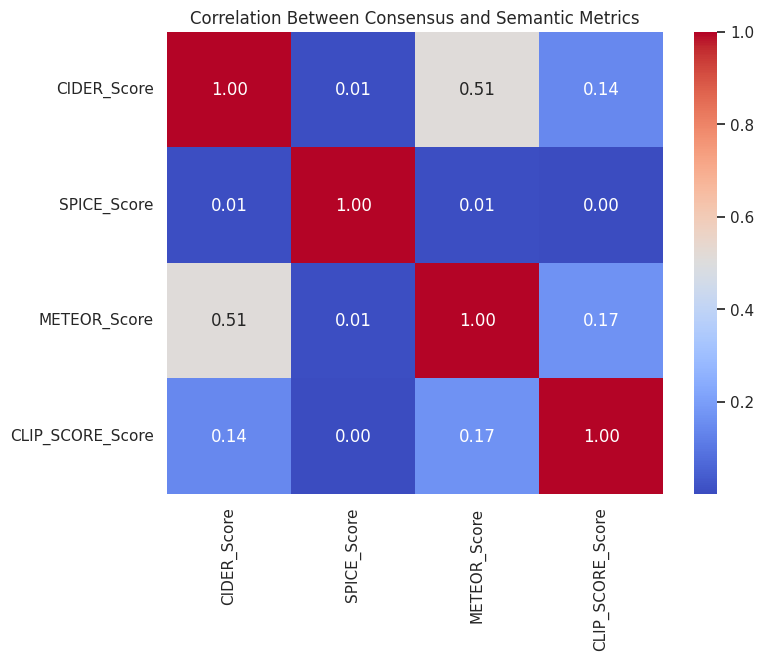

In [5]:
# Generate histograms for all metrics and a correlation heatmap
score_cols = [c for c in df_all.columns if c.endswith('_Score')]
n_metrics = len(score_cols)

# 1. Distributions Grid
fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4))
if n_metrics == 1: axes = [axes]

for i, col in enumerate(score_cols):
    sns.histplot(data=df_all, x=col, hue='Model', kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{col.replace("_Score", "")} Distribution')

plt.tight_layout()
plt.show()

# 2. Metric Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_all[score_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Consensus and Semantic Metrics")
plt.show()

In [ ]:
# Separate Metric Distributions per Model
# Identify all available metrics
score_cols = [c for c in df_all.columns if c.endswith('_Score')]

# 1. Establish a consistent color palette for all plots
# This ensures that Model A is always Color X, even in separate graphs
unique_models = df_all['Model'].unique()
model_palette = dict(zip(unique_models, sns.color_palette("husl", len(unique_models))))

# 2. Generate faceted plots for each metric
for col in score_cols:
    # We use displot for flexible faceting
    g = sns.displot(
        data=df_all, 
        x=col, 
        col="Model", 
        hue="Model", 
        palette=model_palette,
        kind="hist", 
        kde=True, 
        aspect=1.2, 
        height=4,
        alpha=0.7
    )
    
    # Clean up labels and titles
    metric_name = col.replace("_Score", "")
    g.set_axis_labels(f"{metric_name} Score", "Frequency")
    g.set_titles(col_template="{col_name}")
    g.fig.suptitle(f'Detailed Distribution: {metric_name}', y=1.05, fontsize=14)
    
    plt.show()

--- Viewing 3 Best Samples based on CIDEr_Score ---



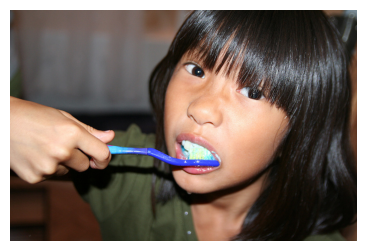

Model: Gemma 4B | Image: 000000544519.jpg
Scores -> CIDEr: 3.5114 | SPICE: 0.1212
Generated Caption:
A young girl is shown brushing her teeth with a blue toothbrush.
--------------------------------------------------------------------------------



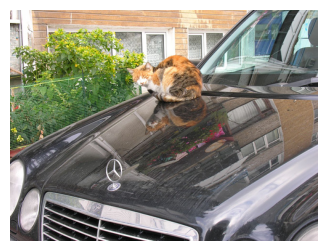

Model: Gemma 4B | Image: 000000023272.jpg
Scores -> CIDEr: 2.3124 | SPICE: 0.1875
Generated Caption:
A cat is resting on the hood of a black Mercedes-Benz parked outdoors.
--------------------------------------------------------------------------------



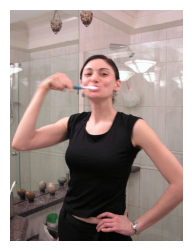

Model: Gemma 4B | Image: 000000465179.jpg
Scores -> CIDEr: 2.1452 | SPICE: 0.1250
Generated Caption:
A young woman in a black top is brushing her teeth in a modern bathroom.
--------------------------------------------------------------------------------



In [9]:
#image sampler 

def view_samples(df, num_samples=3, sort_by=None, ascending=True):
    """
    sort_by: 'CIDEr_Score' or 'SPICE_Score' (views lowest scores if ascending=True)
    Leave sort_by=None for purely random samples.
    """
    if sort_by:
        sample_df = df.sort_values(by=sort_by, ascending=ascending).head(num_samples)
        order = "Worst" if ascending else "Best"
        print(f"--- Viewing {num_samples} {order} Samples based on {sort_by} ---\n")
    else:
        sample_df = df.sample(num_samples)
        print(f"--- Viewing {num_samples} Random Samples ---\n")
        
    for _, row in sample_df.iterrows():
        # Handle COCO ID formatting (e.g., 456865 -> 000000456865.jpg)
        img_id_str = str(row['Image_ID'])
        if not img_id_str.endswith('.jpg'):
            img_id_str = img_id_str.zfill(12) + '.jpg'
            
        img_path = os.path.join(IMAGES_DIR, img_id_str)
        
        # Display Image
        try:
            img = Image.open(img_path)
            plt.figure(figsize=(5, 3))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
        except FileNotFoundError:
            print(f"[Image not found at {img_path}]")
        
        # Display Metrics & Text
        print(f"Model: {row['Model']} | Image: {img_id_str}")
        print(f"Scores -> CIDEr: {row['CIDEr_Score']:.4f} | SPICE: {row['SPICE_Score']:.4f}")
        
        wrapped_caption = textwrap.fill(row['Generated_Caption'], width=80)
        print(f"Generated Caption:\n{wrapped_caption}")
        print("-" * 80 + "\n")

# Run Examples:
# view_samples(df_all, num_samples=3) # Random
view_samples(df_all, num_samples=3, sort_by='CIDEr_Score', ascending=False) # The 3 worst SPICE performers